In [1]:
!pip install webdataset --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.0 MB/s eta 0:00:00


In [2]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

from config import mount_drive
mount_drive()

Mounted at /content/drive


# Experiment 03 - Regularization + Augmentation

**Goal:** Show the effect of Dropout, BatchNorm, weight decay, and data augmentation.  
**Models trained:**
- `DeepCNNRegularized` (Dropout only)
- `DeepCNNBatchNorm` (BatchNorm only)
- `DeepCNNBatchNormRegularized` (BN + Dropout)
- `DeepCNNBatchNormRegularized` + **augmentation** (rotation, jitter, erasing)

All compared head-to-head on the same test split.

In [4]:
import torch.nn as nn
import pandas as pd
from config import load_config
from augmentation import build_train_transform, build_eval_transform
from dataset import build_dataloaders
from model import DeepCNNRegularized, DeepCNNBatchNorm, DeepCNNBatchNormRegularized
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model, evaluate_model

cfg = load_config(ROOT / 'content/configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)

num_classes = len(cfg.classes)
image_size = cfg.preprocessing.image_size

eval_tf = build_eval_transform(image_size, use_imagenet_norm=False)
train_tf = build_train_transform(image_size, use_imagenet_norm=False)

class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

[config] environment: colab


In [ ]:
import json, time
import numpy as np
import torch

def run_experiment(model, exp_name, use_augmentation=False):
    tf_train = train_tf if use_augmentation else eval_tf
    train_loader, val_loader, test_loader = build_dataloaders(
        train_transform=tf_train,
        eval_transform=eval_tf,
        **cfg.dataloader_kwargs(),
    )
    trainer = Trainer(
        model=model, train_loader=train_loader, val_loader=val_loader,
        device=cfg.device, exp_name=exp_name,
        results_root=cfg.results_root, checkpoints_root=cfg.checkpoints_root,
        num_epochs=cfg.training.num_epochs,
        learning_rate=cfg.training.learning_rate, weight_decay=cfg.training.weight_decay,
        grad_clip=cfg.training.grad_clip, grad_accum_steps=cfg.training.grad_accum_steps,
        early_stopping_patience=cfg.training.early_stopping_patience,
        use_amp=cfg.training.use_amp, scheduler=cfg.training.scheduler,
        class_weights=class_weights, num_classes=num_classes,
        debug=cfg.debug,
    )
    history = trainer.train()

    best_ckpt = cfg.checkpoints_root / exp_name / 'best.pt'
    model = load_model(model, str(best_ckpt), cfg.device)
    test_loss, test_acc, f1, bal, true_l, pred_l = evaluate_model(model, test_loader, cfg.device, nn.CrossEntropyLoss())
    print(f'{exp_name:35s}  Macro-F1={f1:.4f}  Balanced-Acc={bal:.4f}')

    results_dir = cfg.results_root / exp_name
    np.save(str(results_dir / 'y_true.npy'), np.array(true_l))
    np.save(str(results_dir / 'y_pred.npy'), np.array(pred_l))

    model.eval()
    dummy = torch.randn(1, 3, image_size, image_size).to(cfg.device)
    with torch.no_grad():
        for _ in range(10): model(dummy)
        t0 = time.perf_counter()
        for _ in range(100): model(dummy)
        latency_ms = (time.perf_counter() - t0) / 100 * 1000

    num_params_m = sum(p.numel() for p in model.parameters()) / 1e6
    total_time_s = sum(history['epoch_time_s'])

    test_summary = {
        'exp_name': exp_name,
        'model': type(model).__name__,
        'test_loss': round(test_loss, 6),
        'test_acc': round(test_acc, 6),
        'test_macro_f1': round(f1, 6),
        'test_balanced_acc': round(bal, 6),
        'inference_latency_ms': round(latency_ms, 3),
        'num_params_M': round(num_params_m, 2),
        'phase1_epochs': len(history['train_loss']),
        'phase2_epochs': 0,
        'phase1_time_s': round(total_time_s, 1),
        'phase2_time_s': 0.0,
        'total_training_time_s': round(total_time_s, 1),
    }
    with open(results_dir / 'test_results.json', 'w') as f:
        json.dump(test_summary, f, indent=2)
    print(f'  Saved y_true.npy, y_pred.npy, test_results.json -> {results_dir}')

    return f1, bal


  Experiment: deep_dropout
  Device: cuda  |  AMP: True  |  Epochs: 30


Epoch 001/30  train_loss=3.6160  train_acc=0.0195  val_loss=3.6109  val_acc=0.0274  val_F1=0.0024  [302.3s]
  New best val macro-F1=0.0024 - checkpoint saved


Epoch 002/30  train_loss=3.6073  train_acc=0.0352  val_loss=3.6088  val_acc=0.0603  val_F1=0.0227  [40.8s]
  New best val macro-F1=0.0227 - checkpoint saved


Epoch 003/30  train_loss=3.5848  train_acc=0.0781  val_loss=3.6056  val_acc=0.0356  val_F1=0.0114  [12.3s]


Epoch 004/30  train_loss=3.5408  train_acc=0.0430  val_loss=3.6049  val_acc=0.0356  val_F1=0.0117  [6.7s]


...

Epoch 026/30  train_loss=2.6366  train_acc=0.2578  val_loss=3.2209  val_acc=0.1562  val_F1=0.1286  [4.5s]


Epoch 027/30  train_loss=2.7138  train_acc=0.2266  val_loss=3.2186  val_acc=0.1562  val_F1=0.1291  [4.3s]


Epoch 028/30  train_loss=2.7010  train_acc=0.2344  val_loss=3.2173  val_acc=0.1507  val_F1=0.1254  [5.4s]


Epoch 029/30  train_loss=2.6921  train_acc=0.2266  val_loss=3.2166  val_acc=0.1507  val_F1=0.1261  [4.6s]


Epoch 030/30  train_loss=2.7521  train_acc=0.2109  val_loss=3.2164  val_acc=0.1507  val_F1=0.1261  [4.4s]


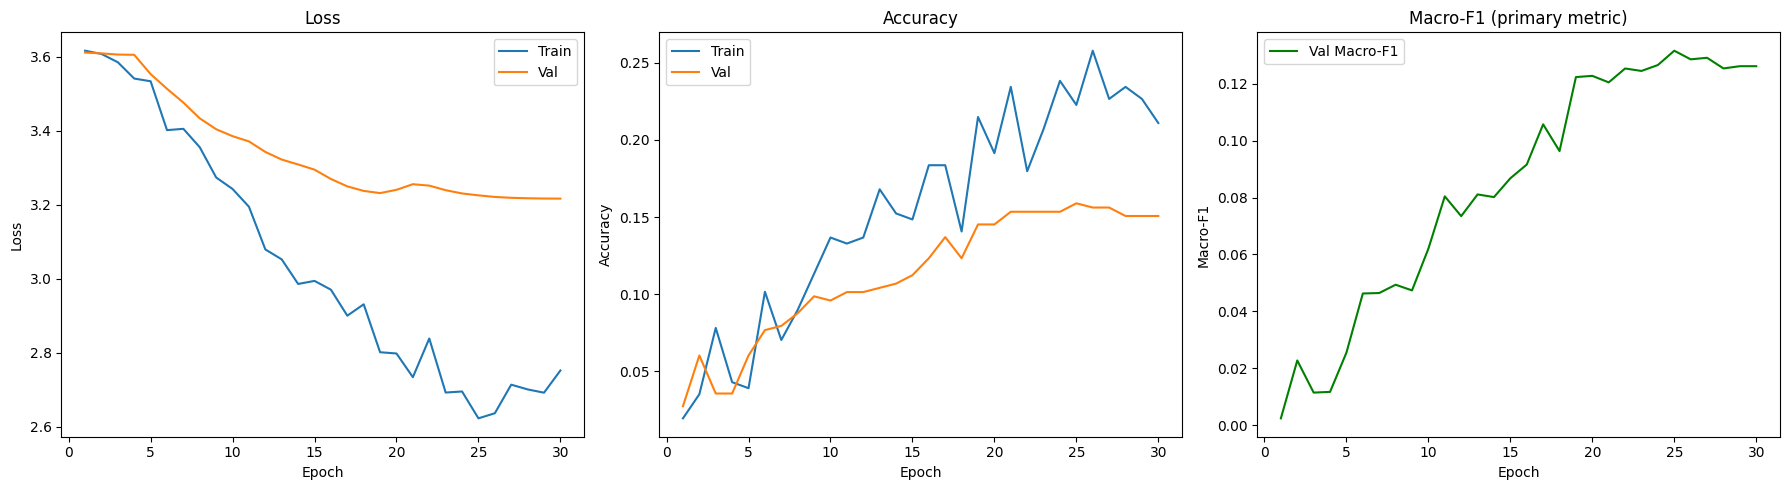

deep_dropout                         Macro-F1=0.0857  Balanced-Acc=0.1071

  Experiment: deep_batchnorm
  Device: cuda  |  AMP: True  |  Epochs: 30


Epoch 001/30  train_loss=3.7370  train_acc=0.0273  val_loss=3.6088  val_acc=0.0301  val_F1=0.0070  [5.2s]
  New best val macro-F1=0.0070 - checkpoint saved


Epoch 002/30  train_loss=3.4251  train_acc=0.0664  val_loss=3.5885  val_acc=0.0438  val_F1=0.0050  [6.0s]


Epoch 003/30  train_loss=3.1577  train_acc=0.1289  val_loss=3.5492  val_acc=0.0877  val_F1=0.0385  [5.1s]
  New best val macro-F1=0.0385 - checkpoint saved


Epoch 004/30  train_loss=2.9294  train_acc=0.1953  val_loss=3.5256  val_acc=0.0329  val_F1=0.0109  [5.6s]


...

Epoch 006/30  train_loss=2.5943  train_acc=0.3008  val_loss=3.6076  val_acc=0.0274  val_F1=0.0045  [4.9s]


Epoch 007/30  train_loss=2.3634  train_acc=0.3555  val_loss=3.6372  val_acc=0.0411  val_F1=0.0147  [5.8s]


Epoch 008/30  train_loss=2.2434  train_acc=0.3984  val_loss=3.7667  val_acc=0.0274  val_F1=0.0023  [5.2s]


Epoch 009/30  train_loss=2.0990  train_acc=0.4102  val_loss=3.7936  val_acc=0.0274  val_F1=0.0023  [4.7s]


Epoch 010/30  train_loss=1.9823  train_acc=0.4648  val_loss=3.7118  val_acc=0.0247  val_F1=0.0035  [5.8s]
  Early stopping triggered at epoch 10.


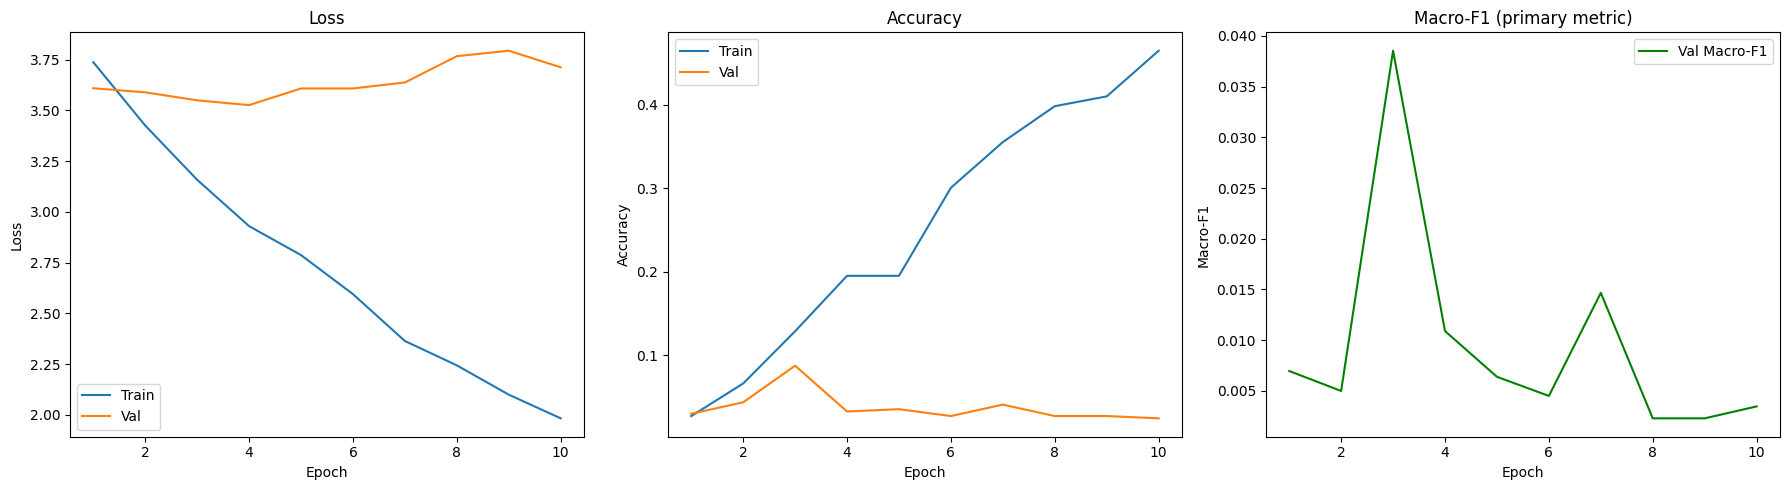

deep_batchnorm                       Macro-F1=0.0231  Balanced-Acc=0.0644

  Experiment: deep_bn_dropout
  Device: cuda  |  AMP: True  |  Epochs: 30


Epoch 001/30  train_loss=3.7413  train_acc=0.0195  val_loss=3.6087  val_acc=0.0274  val_F1=0.0019  [4.9s]
  New best val macro-F1=0.0019 - checkpoint saved


Epoch 002/30  train_loss=3.6818  train_acc=0.0586  val_loss=3.5998  val_acc=0.0548  val_F1=0.0247  [5.8s]
  New best val macro-F1=0.0247 - checkpoint saved


Epoch 003/30  train_loss=3.4198  train_acc=0.0859  val_loss=3.5749  val_acc=0.0795  val_F1=0.0397  [4.8s]
  New best val macro-F1=0.0397 - checkpoint saved


Epoch 004/30  train_loss=3.3053  train_acc=0.1055  val_loss=3.5412  val_acc=0.0849  val_F1=0.0481  [4.8s]
  New best val macro-F1=0.0481 - checkpoint saved


...

Epoch 026/30  train_loss=2.1678  train_acc=0.3906  val_loss=2.9955  val_acc=0.1726  val_F1=0.1426  [5.4s]
  New best val macro-F1=0.1426 - checkpoint saved


Epoch 027/30  train_loss=2.0678  train_acc=0.4219  val_loss=2.9867  val_acc=0.1808  val_F1=0.1505  [5.4s]
  New best val macro-F1=0.1505 - checkpoint saved


Epoch 028/30  train_loss=2.1760  train_acc=0.3398  val_loss=2.9796  val_acc=0.1726  val_F1=0.1427  [4.8s]


Epoch 029/30  train_loss=2.1105  train_acc=0.4023  val_loss=2.9761  val_acc=0.1753  val_F1=0.1492  [5.8s]


Epoch 030/30  train_loss=2.0938  train_acc=0.3906  val_loss=2.9725  val_acc=0.1753  val_F1=0.1491  [4.9s]


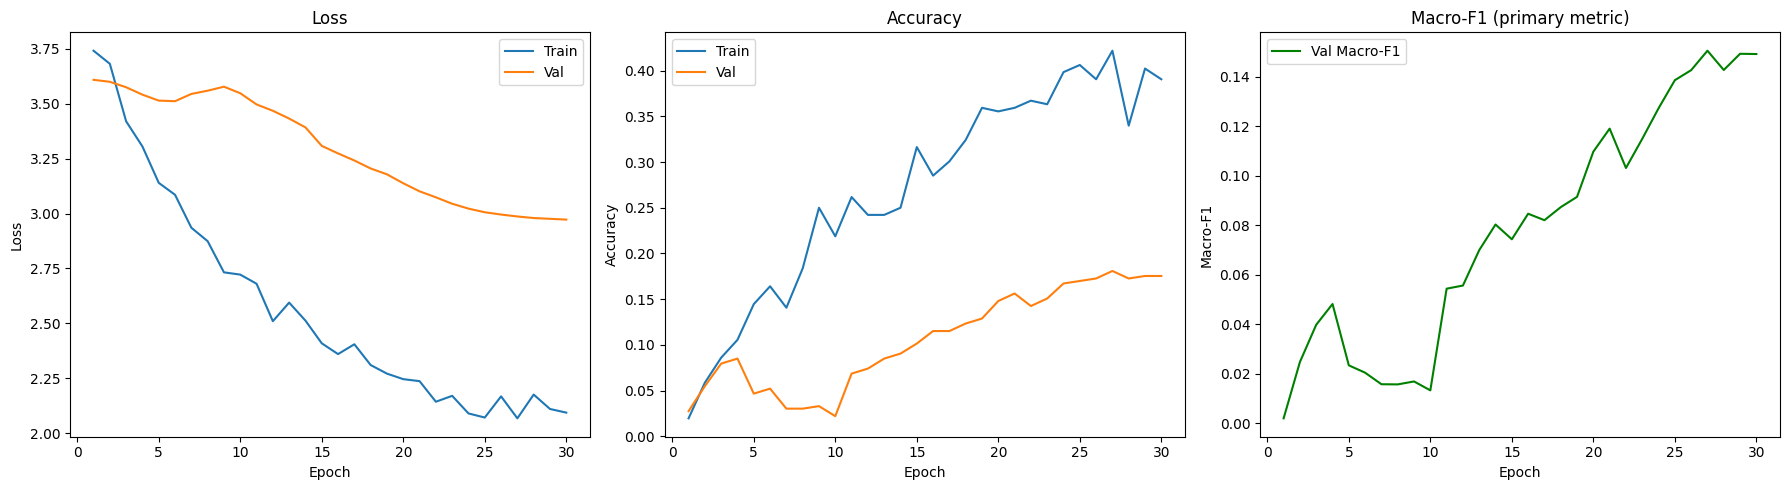

deep_bn_dropout                      Macro-F1=0.1392  Balanced-Acc=0.1597

  Experiment: deep_bn_dropout_aug
  Device: cuda  |  AMP: True  |  Epochs: 30


Epoch 001/30  train_loss=3.8268  train_acc=0.0273  val_loss=3.6121  val_acc=0.0438  val_F1=0.0065  [8.0s]
  New best val macro-F1=0.0065 - checkpoint saved


Epoch 002/30  train_loss=3.7571  train_acc=0.0469  val_loss=3.6065  val_acc=0.0110  val_F1=0.0015  [6.5s]


Epoch 003/30  train_loss=3.6036  train_acc=0.0508  val_loss=3.5930  val_acc=0.0438  val_F1=0.0074  [7.6s]
  New best val macro-F1=0.0074 - checkpoint saved


Epoch 004/30  train_loss=3.5353  train_acc=0.0469  val_loss=3.5716  val_acc=0.0384  val_F1=0.0050  [6.5s]


...

Epoch 026/30  train_loss=2.8427  train_acc=0.1797  val_loss=3.0570  val_acc=0.1589  val_F1=0.1554  [6.7s]


Epoch 027/30  train_loss=2.8539  train_acc=0.1875  val_loss=3.0410  val_acc=0.1562  val_F1=0.1521  [7.6s]


Epoch 028/30  train_loss=2.9728  train_acc=0.1562  val_loss=3.0290  val_acc=0.1589  val_F1=0.1548  [7.0s]


Epoch 029/30  train_loss=2.8797  train_acc=0.1719  val_loss=3.0206  val_acc=0.1562  val_F1=0.1511  [7.6s]


Epoch 030/30  train_loss=2.8218  train_acc=0.1758  val_loss=3.0134  val_acc=0.1534  val_F1=0.1452  [6.5s]


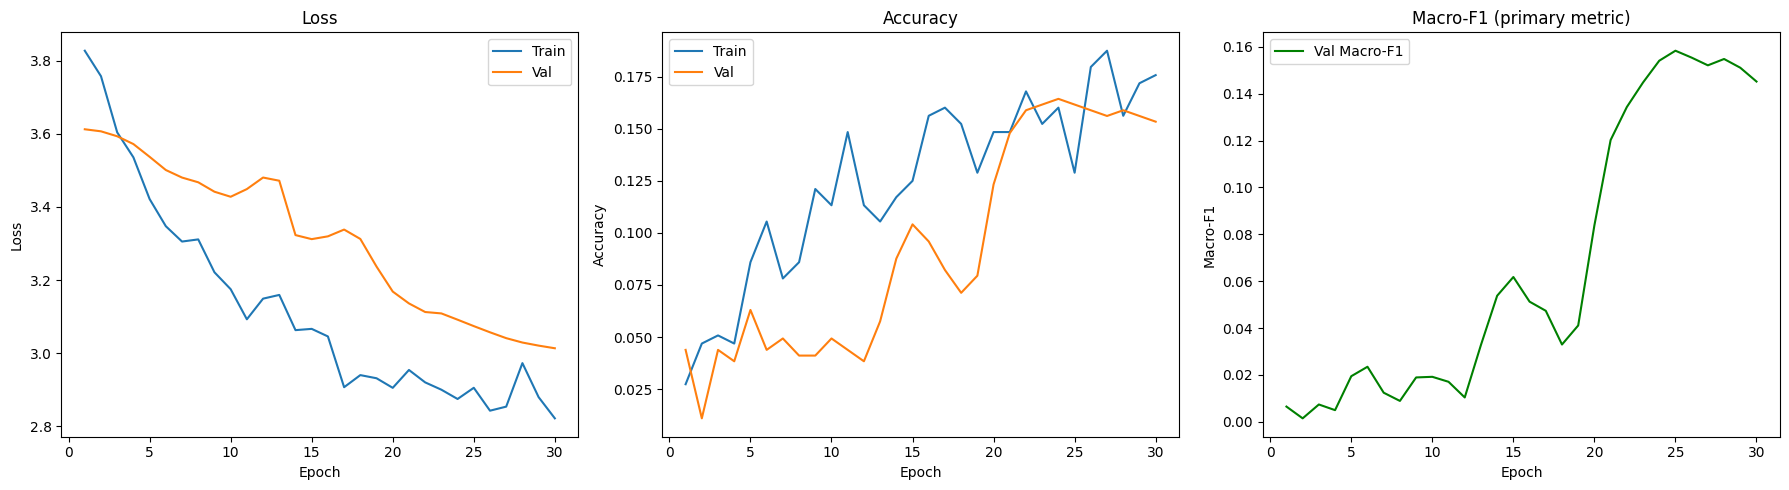

deep_bn_dropout_aug                  Macro-F1=0.1071  Balanced-Acc=0.1386

--- Summary ---
  BN+Dropout               : Macro-F1 = 0.1392
  BN+Dropout+Aug           : Macro-F1 = 0.1071
  Dropout                  : Macro-F1 = 0.0857
  BatchNorm                : Macro-F1 = 0.0231


In [6]:
results = {}

f1, bal = run_experiment(DeepCNNRegularized(3, num_classes), 'deep_dropout')
results['Dropout'] = f1

f1, bal = run_experiment(DeepCNNBatchNorm(3, num_classes), 'deep_batchnorm')
results['BatchNorm'] = f1

f1, bal = run_experiment(DeepCNNBatchNormRegularized(3, num_classes), 'deep_bn_dropout')
results['BN+Dropout'] = f1

f1, bal = run_experiment(DeepCNNBatchNormRegularized(3, num_classes), 'deep_bn_dropout_aug', use_augmentation=True)
results['BN+Dropout+Aug'] = f1

print('\n--- Summary ---')
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {k:25s}: Macro-F1 = {v:.4f}')